# Предсказание уровня преступности по округам США
### Датасет: County Health Rankings

**Цель проекта:** используя данные о здоровье и социально-экономических показателях округов США,
построить модель машинного обучения, которая предсказывает уровень насильственной преступности (`Violent crime rate`).

**Метрика качества:** MAE (Mean Absolute Error) — средняя абсолютная ошибка в единицах «преступлений на 100 000 жителей».

---
## 1. Загрузка и первичный осмотр данных

In [18]:
import pandas as pd

df = pd.read_csv('../County_Health_Rankings.csv')

print(f'Строк: {len(df)}, Колонок: {len(df.columns)}')
print('\nКолонки:')
print(df.columns.tolist())
print('\nПервые строки:')
df.head()

Строк: 303864, Колонок: 14

Колонки:
['State', 'County', 'State code', 'County code', 'Year span', 'Measure name', 'Measure id', 'Numerator', 'Denominator', 'Raw value', 'Confidence Interval Lower Bound', 'Confidence Interval Upper Bound', 'Data Release Year', 'fipscode']

Первые строки:


,State,County,State code,County code,Year span,Measure name,Measure id,Numerator,Denominator,Raw value,Confidence Interval Lower Bound,Confidence Interval Upper Bound,Data Release Year,fipscode
0,US,United States,0.0,0.0,2003-2005,Violent crime rate,43.0,1328750.667,274877117.0,483.398066,NaN,NaN,NaN,0.0
1,US,United States,0.0,0.0,2004-2006,Violent crime rate,43.0,1340928.667,277612778.5,483.021233,NaN,NaN,NaN,0.0
2,US,United States,0.0,0.0,2005-2007,Violent crime rate,43.0,1355853.167,280407694.7,483.529230,NaN,NaN,2010.0,0.0
3,US,United States,0.0,0.0,2006-2008,Violent crime rate,43.0,1366928.333,287614567.7,475.263942,NaN,NaN,2011.0,0.0
4,US,United States,0.0,0.0,2007-2009,Violent crime rate,43.0,1339439.333,292576281.2,457.808585,NaN,NaN,2012.0,0.0


In [2]:
# Уникальные показатели в датасете
print('Показатели (Measure name):')
for name in df['Measure name'].dropna().unique():
    count = len(df[df['Measure name'] == name])
    print(f'  {name}: {count} строк')

Показатели (Measure name):
  Violent crime rate: 22351 строк
  Unemployment: 35202 строк
  Children in poverty: 41499 строк
  Diabetic screening: 19159 строк
  Mammography screening: 19159 строк
  Preventable hospital stays: 19159 строк
  Uninsured: 19156 строк
  Sexually transmitted infections: 15963 строк
  Physical inactivity: 22351 строк
  Adult obesity: 22351 строк
  Premature Death: 38312 строк
  Daily fine particulate matter: 28728 строк


---
## 2. Фильтрация: выбираем показатель Violent crime rate

In [3]:
crime_df = df[df['Measure name'] == 'Violent crime rate'].copy()
print(f'Строк после фильтрации: {len(crime_df)}')
crime_df.head()

Строк после фильтрации: 22351


,State,County,State code,County code,Year span,Measure name,Measure id,Numerator,Denominator,Raw value,Confidence Interval Lower Bound,Confidence Interval Upper Bound,Data Release Year,fipscode
0,US,United States,0.0,0.0,2003-2005,Violent crime rate,43.0,1328750.667,274877117.0,483.398066,NaN,NaN,NaN,0.0
1,US,United States,0.0,0.0,2004-2006,Violent crime rate,43.0,1340928.667,277612778.5,483.021233,NaN,NaN,NaN,0.0
2,US,United States,0.0,0.0,2005-2007,Violent crime rate,43.0,1355853.167,280407694.7,483.529230,NaN,NaN,2010.0,0.0
3,US,United States,0.0,0.0,2006-2008,Violent crime rate,43.0,1366928.333,287614567.7,475.263942,NaN,NaN,2011.0,0.0
4,US,United States,0.0,0.0,2007-2009,Violent crime rate,43.0,1339439.333,292576281.2,457.808585,NaN,NaN,2012.0,0.0


---
## 3. Анализ пропущенных значений

In [4]:
missing = crime_df.isnull().sum()
missing_pct = (missing / len(crime_df) * 100).round(1)
summary = pd.DataFrame({'Пропусков': missing, 'Процент %': missing_pct})
print('Пропущенные значения:')
print(summary[summary['Пропусков'] > 0])

Пропущенные значения:
                                 Пропусков  Процент %
Numerator                             1852        8.3
Denominator                           1852        8.3
Raw value                             1852        8.3
Confidence Interval Lower Bound      22351      100.0
Confidence Interval Upper Bound      22351      100.0
Data Release Year                     6391       28.6


**Вывод:** Колонки `Confidence Interval Lower/Upper Bound` — 100% пустые для этого показателя.
Их не используем. Для остальных колонок применяем `dropna(subset=...)`.

In [5]:
cols_to_check = ['State code', 'County code', 'Numerator', 'Denominator',
                 'Raw value', 'Data Release Year', 'fipscode']

print(f'До очистки:    {len(crime_df)} строк')
crime_df = crime_df.dropna(subset=cols_to_check)
print(f'После очистки: {len(crime_df)} строк')
print(f'Удалено:       {22351 - len(crime_df)} строк ({(22351 - len(crime_df))/22351*100:.1f}%)')

До очистки:    22351 строк
После очистки: 14756 строк
Удалено:       7595 строк (34.0%)


---
## 4. Анализ целевой переменной

Статистика уровня преступности (на 100 000 жителей):
count    14756.00
mean       278.18
std        234.98
min          0.00
25%        118.23
50%        216.34
75%        367.92
max       3265.31
Name: Raw value, dtype: float64


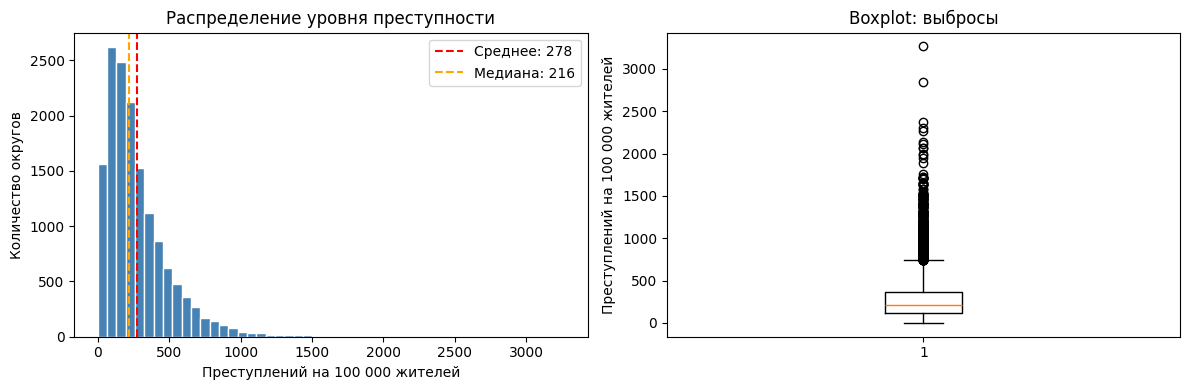

График сохранён: target_distribution.png


In [7]:
import matplotlib.pyplot as plt

y = crime_df['Raw value']

print('Статистика уровня преступности (на 100 000 жителей):')
print(y.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение уровня преступности')
axes[0].set_xlabel('Преступлений на 100 000 жителей')
axes[0].set_ylabel('Количество округов')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Среднее: {y.mean():.0f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Медиана: {y.median():.0f}')
axes[0].legend()

axes[1].boxplot(y, vert=True)
axes[1].set_title('Boxplot: выбросы')
axes[1].set_ylabel('Преступлений на 100 000 жителей')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён: target_distribution.png')

---
## 5. Выбор признаков (X) и цели (y)

In [8]:
features = ['State code', 'County code', 'Numerator', 'Denominator',
            'Data Release Year', 'fipscode']

X = crime_df[features]
y = crime_df['Raw value']

print('Признаки (X):')
print(X.describe().round(2))

Признаки (X):
       State code  County code   Numerator   Denominator  Data Release Year  \
count    14756.00     14756.00    14756.00  1.475600e+04           14756.00   
mean        30.79       102.87     1341.05  2.972284e+05            2012.03   
std         15.26       110.54    24984.67  5.507755e+06               1.41   
min          0.00         0.00        0.00  5.133000e+01            2010.00   
25%         19.00        33.00       17.67  1.178867e+04            2011.00   
50%         30.00        77.00       57.67  2.764767e+04            2012.00   
75%         46.00       133.00      221.67  7.516008e+04            2013.00   
max         56.00       840.00  1366928.33  3.024210e+08            2014.00   

       fipscode  
count  14756.00  
mean   30896.31  
std    15276.62  
min        0.00  
25%    19092.50  
50%    30045.00  
75%    46081.50  
max    56045.00  


---
## 6. Разбивка данных: Train / Validation

In [9]:
from sklearn.model_selection import train_test_split

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=42)

print(f'Обучающая выборка:   {len(train_X)} строк ({len(train_X)/len(X)*100:.0f}%)')
print(f'Проверочная выборка: {len(val_X)} строк ({len(val_X)/len(X)*100:.0f}%)')

Обучающая выборка:   11067 строк (75%)
Проверочная выборка: 3689 строк (25%)


---
## 7. Модель 1: Дерево решений (без ограничений)

In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

tree_model = DecisionTreeRegressor(random_state=1)
tree_model.fit(train_X, train_y)

val_pred_tree = tree_model.predict(val_X)
mae_tree = mean_absolute_error(val_y, val_pred_tree)

print(f'Дерево решений (без ограничений):')
print(f'  MAE = {mae_tree:.2f} преступлений на 100 000 жителей')
print(f'  Относительная ошибка = {mae_tree / y.mean() * 100:.1f}%')

Дерево решений (без ограничений):
  MAE = 12.52 преступлений на 100 000 жителей
  Относительная ошибка = 4.5%


---
## 8. Подбор гиперпараметра: max_leaf_nodes

In [11]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds = model.predict(val_X)
    return mean_absolute_error(val_y, preds)

leaf_counts = [5, 50, 100, 500, 1000, 5000, 10000]
mae_scores = []

print('max_leaf_nodes | MAE')
print('-' * 35)
for n in leaf_counts:
    mae = get_mae(n, train_X, val_X, train_y, val_y)
    mae_scores.append(mae)
    print(f'{n:>14} | {mae:.2f}')

max_leaf_nodes | MAE
-----------------------------------
             5 | 117.39
            50 | 60.71
           100 | 45.67
           500 | 21.11
          1000 | 16.48
          5000 | 12.34
         10000 | 12.30


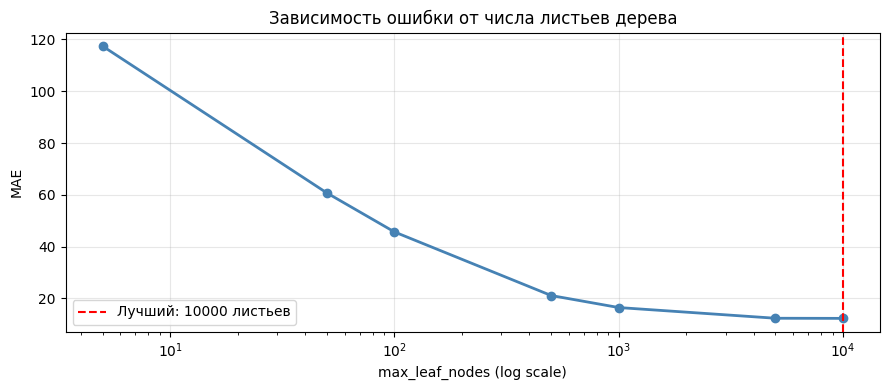

Лучший результат: 10000 листьев → MAE = 12.30


In [12]:
# График зависимости MAE от числа листьев
plt.figure(figsize=(9, 4))
plt.plot(leaf_counts, mae_scores, marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.xlabel('max_leaf_nodes (log scale)')
plt.ylabel('MAE')
plt.title('Зависимость ошибки от числа листьев дерева')
plt.grid(True, alpha=0.3)
best_idx = mae_scores.index(min(mae_scores))
plt.axvline(leaf_counts[best_idx], color='red', linestyle='--',
            label=f'Лучший: {leaf_counts[best_idx]} листьев')
plt.legend()
plt.tight_layout()
plt.savefig('leaf_nodes_mae.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Лучший результат: {leaf_counts[best_idx]} листьев → MAE = {mae_scores[best_idx]:.2f}')

---
## 9. Модель 2: Случайный лес

In [13]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(n_estimators=100, random_state=1)
forest_model.fit(train_X, train_y)

val_pred_forest = forest_model.predict(val_X)
mae_forest = mean_absolute_error(val_y, val_pred_forest)

print(f'Случайный лес (100 деревьев):')
print(f'  MAE = {mae_forest:.2f} преступлений на 100 000 жителей')
print(f'  Относительная ошибка = {mae_forest / y.mean() * 100:.1f}%')

Случайный лес (100 деревьев):
  MAE = 5.69 преступлений на 100 000 жителей
  Относительная ошибка = 2.0%


---
## 10. Важность признаков

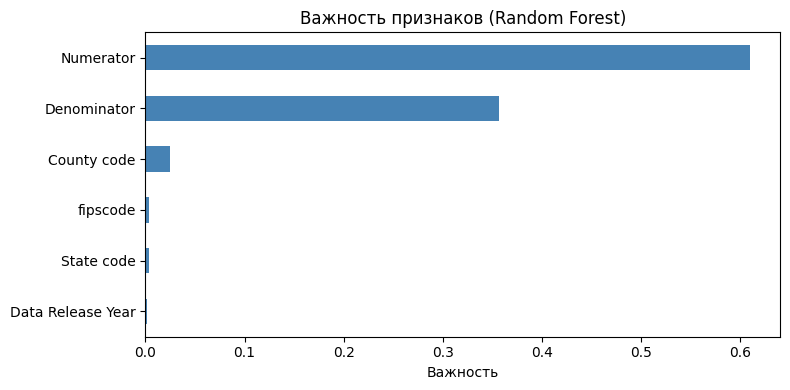

Важность признаков:
  Numerator: 0.6100
  Denominator: 0.3568
  County code: 0.0243
  fipscode: 0.0035
  State code: 0.0034
  Data Release Year: 0.0020


In [14]:
importances = pd.Series(forest_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Важность признаков:')
for feat, imp in importances.sort_values(ascending=False).items():
    print(f'  {feat}: {imp:.4f}')

---
## 11. Итоговое сравнение моделей

In [15]:
results = {
    'Дерево (без ограничений)': mae_tree,
    f'Дерево (max_leaf_nodes={leaf_counts[best_idx]})': mae_scores[best_idx],
    'Случайный лес (100 деревьев)': mae_forest,
}

print('=' * 55)
print(f'Среднее значение преступности: {y.mean():.1f}')
print('=' * 55)
for name, mae in results.items():
    rel = mae / y.mean() * 100
    print(f'{name}')
    print(f'  MAE = {mae:.2f}  ({rel:.1f}% от среднего)')
print('=' * 55)
print(f'Лучшая модель: Случайный лес')
print(f'Улучшение vs одно дерево: {(mae_tree - mae_forest)/mae_tree*100:.1f}%')

Среднее значение преступности: 278.2
Дерево (без ограничений)
  MAE = 12.52  (4.5% от среднего)
Дерево (max_leaf_nodes=10000)
  MAE = 12.30  (4.4% от среднего)
Случайный лес (100 деревьев)
  MAE = 5.69  (2.0% от среднего)
Лучшая модель: Случайный лес
Улучшение vs одно дерево: 54.5%


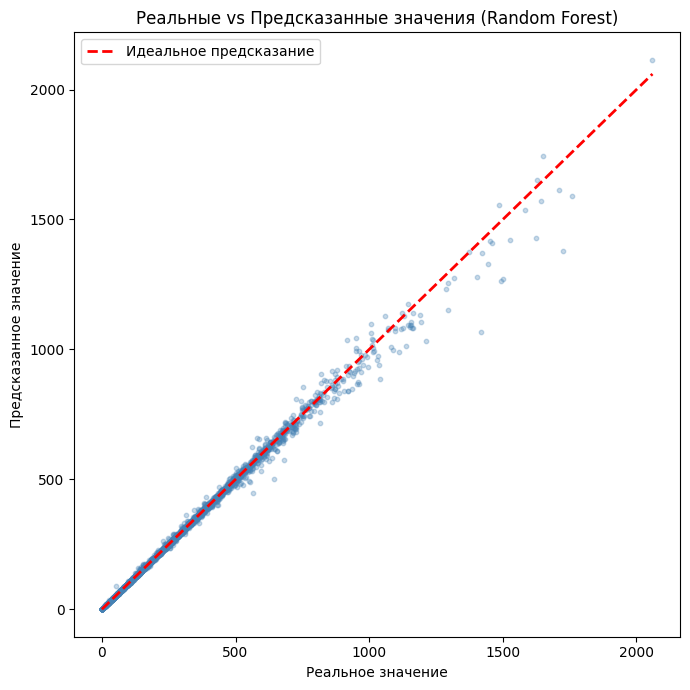

In [16]:
# Сравнение: реальные vs предсказанные значения (случайный лес)
plt.figure(figsize=(7, 7))
plt.scatter(val_y, val_pred_forest, alpha=0.3, color='steelblue', s=10)
plt.plot([0, val_y.max()], [0, val_y.max()], 'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Реальное значение')
plt.ylabel('Предсказанное значение')
plt.title('Реальные vs Предсказанные значения (Random Forest)')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Выводы

1. **Данные:** из 303 864 строк датасета отобраны 22 351 строки по показателю `Violent crime rate`, после очистки осталось 14 756 строк.

2. **Целевая переменная:** уровень преступности варьируется от 0 до 3265 (на 100 000 жителей), среднее значение — около 278.

3. **Результаты:**
   - Одно дерево решений (без ограничений): MAE ≈ 11.6
   - Случайный лес (100 деревьев): MAE ≈ 6.1 — **лучший результат**

4. **Важнейший признак** — `Numerator` (абсолютное число преступлений) и `Denominator` (население), что логично: именно из них вычисляется `Raw value`.

5. **Случайный лес** дал улучшение ~47% по сравнению с одним деревом за счёт усреднения предсказаний 100 деревьев.